# 24b visualize visibility-averaged $A_{
m eff}$

`.py` 側が出力した CSV を読み、thin-shell の $A_{
m unit}$ と visibility-weighted $A_{
m eff}$ を比較する。

ここでは特に $m_{
m res}$ 近傍と $m_{
m best}$ で、thin-shell 近似がどれだけ suppress / enhance されるかを見る。


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path('/home/yminami/workdir/CosmicBirefringence/PatchyReionization')
CSV = ROOT / 'results' / '24-visibility-averaged-aeff' / 'visibility_averaged_aeff_scan.csv'
df = pd.read_csv(CSV).sort_values("mass_eV").reset_index(drop=True)
m_best = df["m_best_eV"].iloc[0]
m_res = df["m_res_fid_eV"].iloc[0]
idx_best = (df["mass_eV"] - m_best).abs().idxmin()
idx_res = (df["mass_eV"] - m_res).abs().idxmin()
summary = pd.concat([df.loc[[idx_res]], df.loc[[idx_best]]], ignore_index=True)
summary[["mass_eV", "A_unit_thinshell", "A_eff_visibility", "Aeff_over_Aunit", "lambda_osc_Mpc", "N_osc_patchy"]]


,mass_eV,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy
0,1.023963e-29,-5.831313e+08,-4.279840e+08,0.733941,34.139000,27.060265
1,5.878016e-27,1.393540e+10,2.065243e+08,0.014820,0.059471,15533.830490


In [5]:
display(summary[["mass_eV", "A_unit_thinshell", "A_eff_visibility", "Aeff_over_Aunit", "lambda_osc_Mpc", "N_osc_patchy"]])
display(df.head())
df.tail()


,mass_eV,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy
0,1.023963e-29,-5.831313e+08,-4.279840e+08,0.733941,34.139000,27.060265
1,5.878016e-27,1.393540e+10,2.065243e+08,0.014820,0.059471,15533.830490


,mass_eV,z_rei,delta_y,R_eff_Mpc,m_best_eV,m_res_fid_eV,m_res_min_eV,m_res_max_eV,phi_unit_at_zrei,dphi_dx_unit_at_zrei,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy,g_norm_z
0,2.330471e-30,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,-0.008193,1.243870,4.715606e+09,-3.655789e+08,-0.077525,150.000000,6.158736,0.049521
1,2.811063e-30,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,0.009175,-0.928003,-3.518128e+09,6.069790e+08,-0.172529,124.355354,7.428795,0.049521
2,3.390762e-30,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,0.008819,-0.581791,-2.205613e+09,3.569580e+07,-0.016184,103.095027,8.960766,0.049521
3,4.090007e-30,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,-0.005446,1.133561,4.297413e+09,-3.527952e+08,-0.082095,85.469457,10.808661,0.049521
4,4.933452e-30,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,0.006013,0.623133,2.362344e+09,-1.456097e+08,-0.061638,70.857231,13.037630,0.049521


,mass_eV,z_rei,delta_y,R_eff_Mpc,m_best_eV,m_res_fid_eV,m_res_min_eV,m_res_max_eV,phi_unit_at_zrei,dphi_dx_unit_at_zrei,A_unit_thinshell,A_eff_visibility,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy,g_norm_z
24,1.195105e-28,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,-0.000198,1.541117,5.842491e+09,-1.024494e+08,-0.017535,2.925022,315.830287,0.049521
25,1.441560e-28,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,-0.000246,-0.966768,-3.665091e+09,-1.146224e+08,0.031274,2.424947,380.961025,0.049521
26,1.738840e-28,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,0.000171,-1.401929,-5.314818e+09,-2.380617e+08,0.044792,2.010368,459.523068,0.049521
27,2.097424e-28,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,0.000155,-1.338395,-5.073956e+09,6.295215e+08,-0.124069,1.666667,554.286229,0.049521
28,5.878016e-27,7.7,19.0,34.139,5.878016e-27,1.023963e-29,6.991414e-30,6.991414e-29,-0.000003,3.675845,1.393540e+10,2.065243e+08,0.014820,0.059471,15533.830490,0.049521


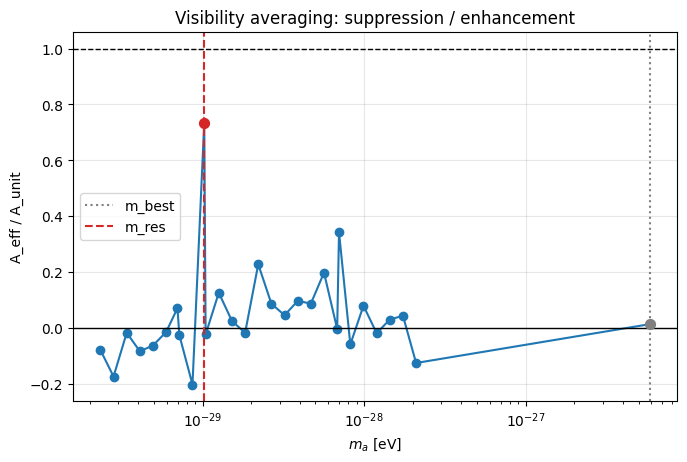

In [6]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.semilogx(df["mass_eV"], df["Aeff_over_Aunit"], marker="o")
ax.axhline(0.0, color="black", ls="-", lw=1)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.axvline(m_best, color="gray", ls=":", lw=1.5, label="m_best")
ax.axvline(m_res, color="C3", ls="--", lw=1.5, label="m_res")
ax.scatter([m_best], [df.loc[idx_best, "Aeff_over_Aunit"]], color="gray", s=50, zorder=5)
ax.scatter([m_res], [df.loc[idx_res, "Aeff_over_Aunit"]], color="C3", s=50, zorder=5)
ax.set_xlabel("$m_a$ [eV]")
ax.set_ylabel("A_eff / A_unit")
ax.set_title("Visibility averaging: suppression / enhancement")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()


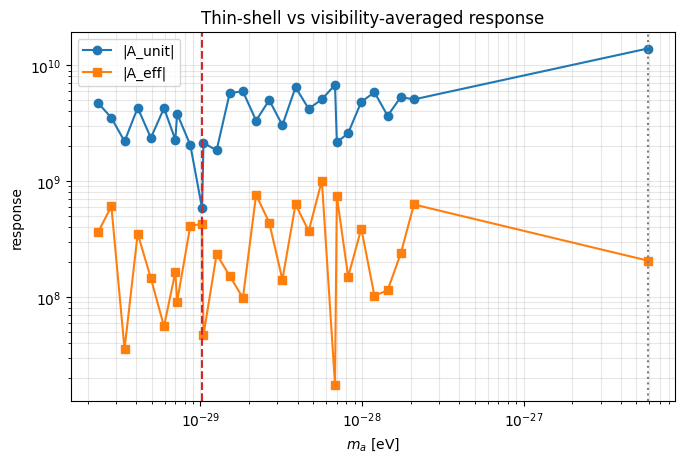

In [7]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.loglog(df["mass_eV"], df["A_unit_thinshell"].abs(), marker="o", label="|A_unit|")
ax.loglog(df["mass_eV"], df["A_eff_visibility"].abs(), marker="s", label="|A_eff|")
ax.axvline(m_best, color="gray", ls=":", lw=1.5)
ax.axvline(m_res, color="C3", ls="--", lw=1.5)
ax.set_xlabel("$m_a$ [eV]")
ax.set_ylabel("response")
ax.set_title("Thin-shell vs visibility-averaged response")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


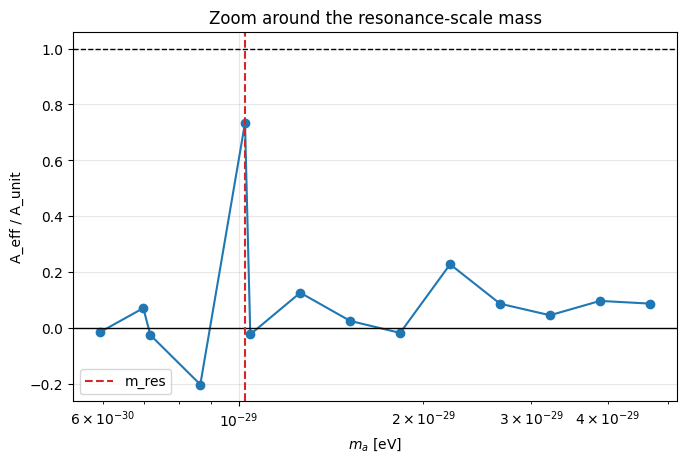

,mass_eV,Aeff_over_Aunit,lambda_osc_Mpc,N_osc_patchy
5,5.950831e-30,-0.013110,58.743173,15.726259
6,6.991414e-30,0.072044,50.000000,18.476208
7,7.178016e-30,-0.024045,48.700187,18.969339
8,8.658271e-30,-0.201056,40.374194,22.881210
9,1.023963e-29,0.733941,34.139000,27.060265
10,1.044379e-29,-0.021976,33.471648,27.599788
11,1.259751e-29,0.127080,27.749190,33.291435
12,1.519538e-29,0.026312,23.005069,40.156818
13,1.832898e-29,-0.016556,19.072024,48.437984
14,2.210879e-29,0.228648,15.811388,58.426899


In [8]:
window = df[(df["mass_eV"] >= 0.5 * m_res) & (df["mass_eV"] <= 5.0 * m_res)].copy()
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.semilogx(window["mass_eV"], window["Aeff_over_Aunit"], marker="o")
ax.axhline(0.0, color="black", ls="-", lw=1)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.axvline(m_res, color="C3", ls="--", lw=1.5, label="m_res")
ax.set_xlabel("$m_a$ [eV]")
ax.set_ylabel("A_eff / A_unit")
ax.set_title("Zoom around the resonance-scale mass")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()
display(window[["mass_eV", "Aeff_over_Aunit", "lambda_osc_Mpc", "N_osc_patchy"]])
